In [6]:
import albumentations as A
from albumentations.pytorch import ToTensorV2

image_transform = A.Compose([
    A.Resize(512, 512),
    A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
    ToTensorV2()
])

mask_transform = A.Compose([
    A.Resize(512, 512),
    ToTensorV2()
])

In [7]:
from torch.utils.data import Dataset
import torch
import cv2
import numpy as np
from pathlib import Path

class SegmentationDataset(Dataset):
    def __init__(self, image_dir, mask_dir, image_transform=None, mask_transform=None):
        self.image_dir = Path(image_dir)
        self.mask_dir = Path(mask_dir)
        self.image_paths = sorted(list(self.image_dir.glob("*.jpg")))
        self.image_transform = image_transform
        self.mask_transform = mask_transform

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        image_path = self.image_paths[idx]
        mask_path = self.mask_dir / image_path.with_suffix(".tif").name

        image = cv2.imread(str(image_path))
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

        mask = cv2.imread(str(mask_path), cv2.IMREAD_GRAYSCALE)

        # Apply transforms
        if self.mask_transform:
            mask = self.mask_transform(image=mask)["image"]
        if self.image_transform:
            image = self.image_transform(image=image)["image"]

        # Make sure mask is a LongTensor for CrossEntropyLoss
        mask = torch.from_numpy(mask).long()

        return image, mask


In [8]:
class MultiLabelSegmentationDataset(Dataset):
    def __init__(self, image_dir, mask_dirs, class_suffixes, transform=None):
        self.image_dir = image_dir
        self.mask_dirs = mask_dirs
        self.class_suffixes = class_suffixes  # dict: {class_name: suffix}
        self.image_filenames = sorted(os.listdir(image_dir))
        self.class_names = list(mask_dirs.keys())
        self.transform = transform

    def __getitem__(self, idx):
        image_name = self.image_filenames[idx]
        image_path = os.path.join(self.image_dir, image_name)
        image = cv2.imread(image_path)
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

        h, w, _ = image.shape
        masks = []
        base_name = image_name.replace('.jpg', '')  # strip extension

        for class_name in self.class_names:
            suffix = self.class_suffixes.get(class_name, '')  # e.g. '_MA'
            mask_filename = f"{base_name}{suffix}.tif"
            mask_path = os.path.join(self.mask_dirs[class_name], mask_filename)

            if os.path.exists(mask_path):
                mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
                mask = (mask > 0).astype(np.uint8)
            else:
                mask = np.zeros((h, w), dtype=np.uint8)
            masks.append(mask)

        mask = np.stack(masks, axis=-1)

        if self.transform:
            augmented = self.transform(image=image, masks=[mask[..., i] for i in range(mask.shape[-1])])
            image = augmented["image"]
            mask = torch.stack([m for m in augmented["masks"]])

        return image, mask
    
    def __len__(self):
        return len(self.image_filenames)


In [9]:
# This one is for multi-label segmentation
transform = A.Compose([
    A.Resize(512, 512),
    A.Normalize(mean=(0.485, 0.456, 0.406),
                std=(0.229, 0.224, 0.225)),
    ToTensorV2()
])

In [10]:
import os
from torch.utils.data import DataLoader

base_image_dir = "/Users/poojasrisundaresan/Desktop/Internship/A. Segmentation/1. Original Images/a. Training Set"
base_mask_dir = "/Users/poojasrisundaresan/Desktop/Internship/A. Segmentation/2. All Segmentation Groundtruths/a. Training Set"

mask_dirs = {
    "Microaneurysms": os.path.join(base_mask_dir, "1. Microaneurysms"),
    "Haemorrhages": os.path.join(base_mask_dir, "2. Haemorrhages"),
    "HardExudates": os.path.join(base_mask_dir, "3. Hard Exudates"),
    "SoftExudates": os.path.join(base_mask_dir, "4. Soft Exudates"),
    "OpticDisc": os.path.join(base_mask_dir, "5. Optic Disc")
}

class_suffixes = {
    "Microaneurysms": "_MA",
    "Haemorrhages": "_HE",
    "HardExudates": "_EX",
    "SoftExudates": "_SE",
    "OpticDisc": "_OD"
}

dataset = MultiLabelSegmentationDataset(base_image_dir, mask_dirs, class_suffixes, transform=transform)
dataloader = DataLoader(dataset, batch_size=4, shuffle=True)

images, masks = next(iter(dataloader))
print("Images:", images.shape)
print("Masks:", masks.shape)


Images: torch.Size([4, 3, 512, 512])
Masks: torch.Size([4, 5, 512, 512])


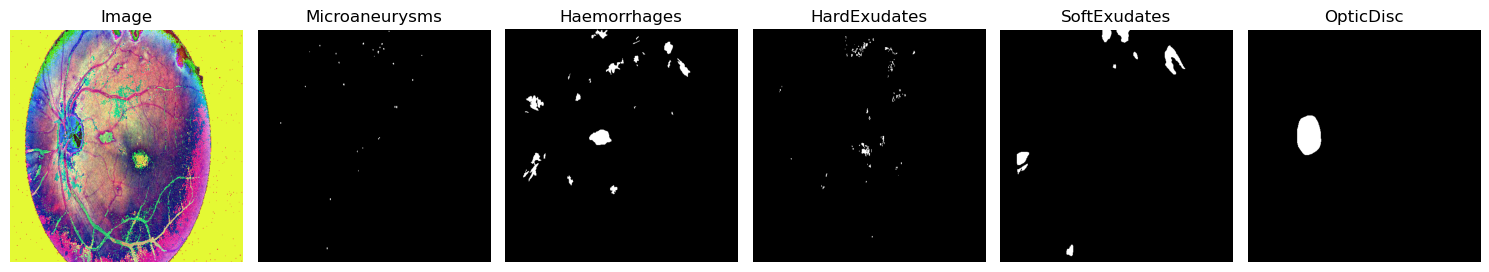

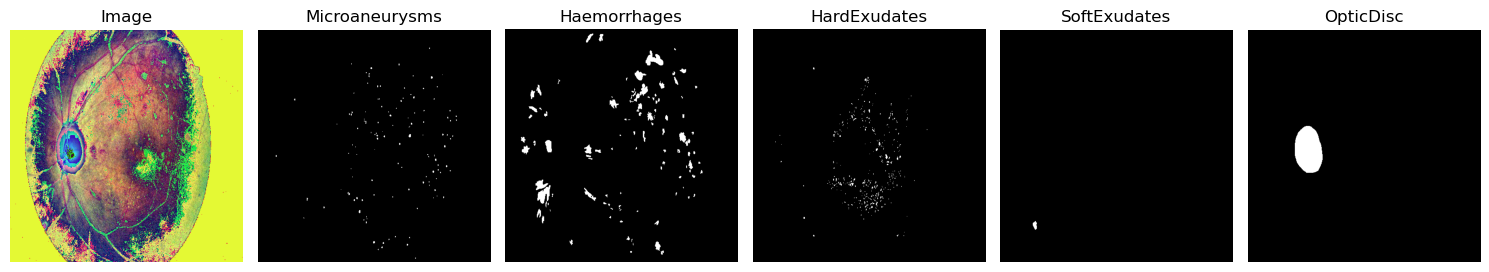

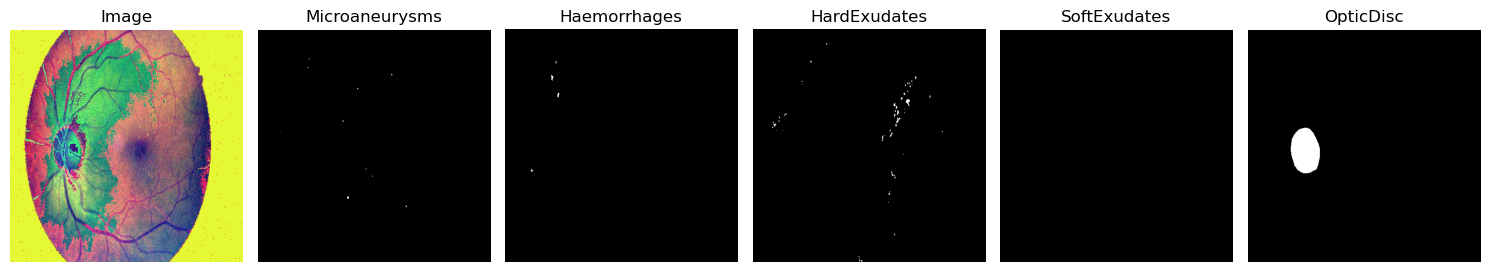

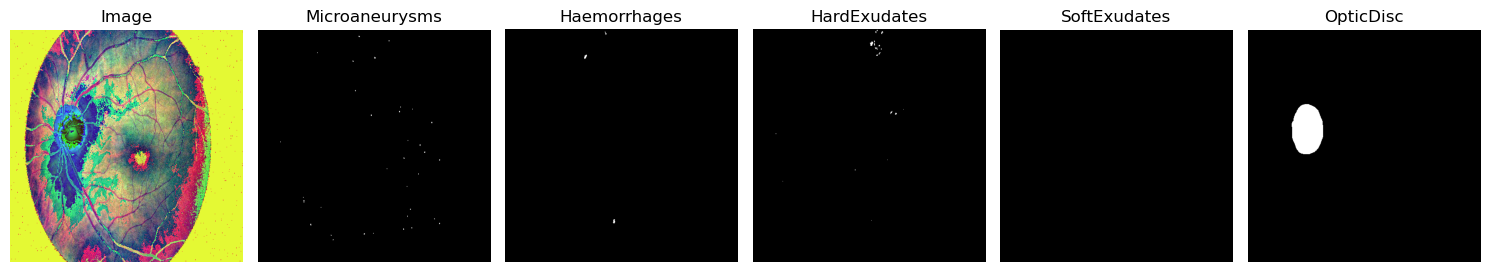

In [11]:
import matplotlib.pyplot as plt

# Get a batch of 4 images and masks
images, masks = next(iter(dataloader))  # images: [B, 3, H, W], masks: [B, 5, H, W]

# Class names in order (to match the mask_dirs dictionary)
class_names = ["Microaneurysms", "Haemorrhages", "HardExudates", "SoftExudates", "OpticDisc"]

# Number of samples to show (max 4 from batch)
num_samples = min(4, images.shape[0])

for i in range(num_samples):
    image = images[i].permute(1, 2, 0).cpu().numpy()  # [3, H, W] → [H, W, 3]
    image = (image * 255).astype('uint8')  # de-normalize if needed

    plt.figure(figsize=(15, 3))
    plt.subplot(1, 6, 1)
    plt.imshow(image)
    plt.title("Image")
    plt.axis("off")

    for j in range(5):
        mask = masks[i][j].cpu().numpy()  # [H, W]
        plt.subplot(1, 6, j+2)
        plt.imshow(mask, cmap='gray')
        plt.title(class_names[j])
        plt.axis("off")
    
    plt.tight_layout()
    plt.show()
